In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [2]:
X, y = make_regression(n_features=1, n_informative=1, n_samples=100, n_targets=1, noise=20, random_state=42)

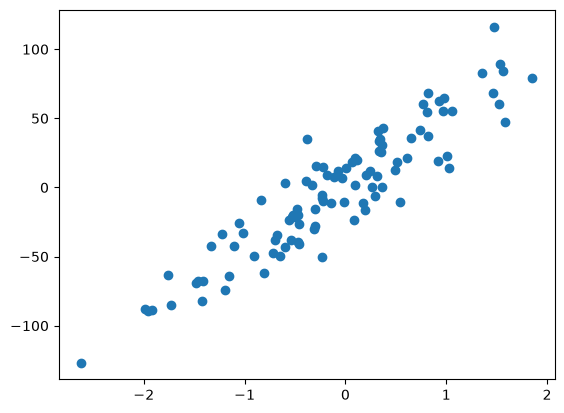

In [3]:
plt.scatter(X, y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
r2_score(y_test, lr.predict(X_test))

0.80190151561592

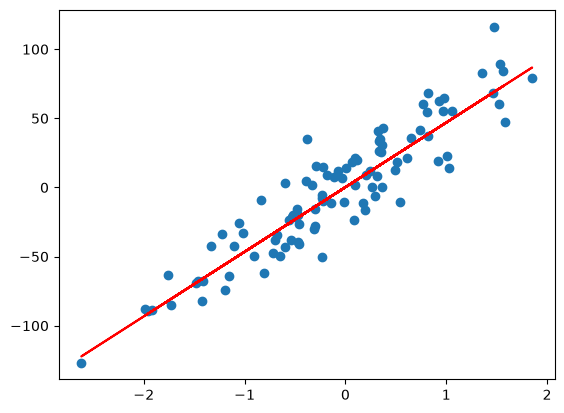

In [6]:
plt.scatter(X, y)
plt.plot(X_train, lr.predict(X_train), color='red')

# Lasso Regression

In [7]:
ls = Lasso(alpha=0.1)
ls.fit(X_train, y_train)
r2_score(y_test, ls.predict(X_test))

0.8016824115697812

0 [46.747264] 0.19844442845176058


/Volumes/SSD/Work/Clones/machine-learning/env/lib/python3.14/site-packages/sklearn/base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)


0.1 [46.62498403] 0.1827125678607775
5 [40.63326581] -0.5881486010973944
10 [34.51926762] -1.3747416306465476
15 [28.40526943] -2.1613346601957018
20 [22.29127125] -2.947927689744856
25 [16.17727306] -3.73452071929401
30 [10.06327487] -4.521113748843165
35 [3.94927668] -5.307706778392318
40 [0.] -5.815798769184627


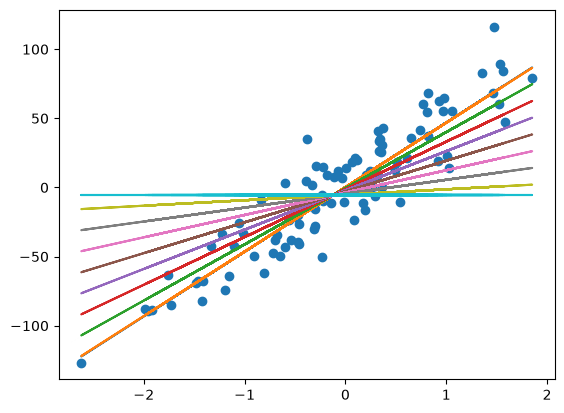

In [8]:
plt.scatter(X, y)
for i in [0, 0.1, 5, 10, 15, 20, 25, 30, 35, 40]:
    lss = Lasso(alpha=i)
    lss.fit(X_train, y_train)
    plt.plot(X_train, lss.predict(X_train))
    print(i, lss.coef_, lss.intercept_)

# Polynomial regression

   Feature_X   Target_Y
0  -3.000000 -54.006572
1  -2.939394 -52.121006
2  -2.878788 -47.505441
3  -2.818182 -42.820958
4  -2.757576 -43.509379


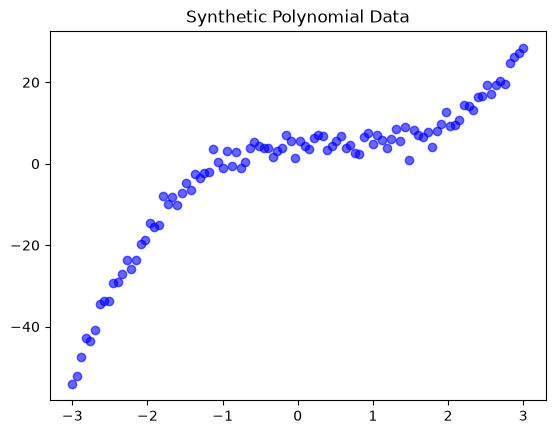

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Set seed for reproducibility
np.random.seed(42)

# 2. Generate independent feature variable (X)
X = np.linspace(-3, 3, 100).reshape(-1, 1)

# 3. Generate dependent variable (y) using a cubic polynomial equation: 
# y = aX^3 + bX^2 + cX + d + noise
noise = np.random.normal(0, 2, X.shape) # Mean=0, StdDev=2
y = (1.5 * X**3) - (2 * X**2) + (0.5 * X) + 5 + noise

# 4. Convert into a clean DataFrame for ML workflows
df = pd.DataFrame(data=np.hstack((X, y)), columns=['Feature_X', 'Target_Y'])
print(df.head())

# Optional: Visualize the curve
plt.scatter(X, y, color='blue', alpha=0.6)
plt.title("Synthetic Polynomial Data")
plt.show()


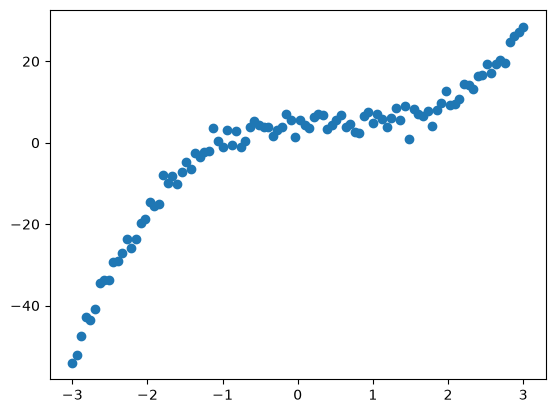

In [10]:
plt.scatter(X, y)

In [11]:
pl = PolynomialFeatures(degree=3)

In [12]:
X_t = pl.fit_transform(X)

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(X_t, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[ 0. , 1.07,-1.96, 1.41]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[4.67]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[106.36, 27.37, 6.92, 0. ]"


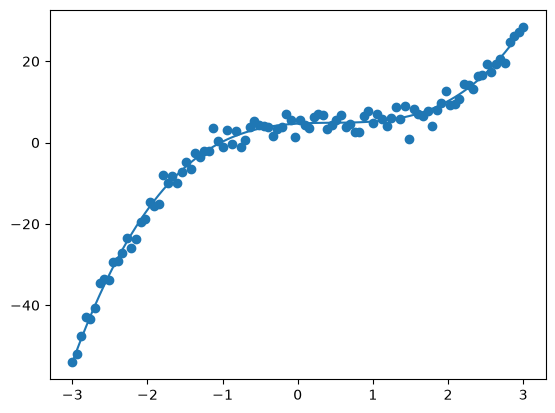

In [15]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X_t))

# Understanding

In [96]:
pll = PolynomialFeatures(degree=300)

In [97]:
X_lasso = pll.fit_transform(X)

In [98]:
lr = LinearRegression()
ls = Lasso(alpha=0)

In [99]:
s= StandardScaler()

In [100]:
X_lasso = s.fit_transform(X_lasso)

In [101]:
lr.fit(X_lasso, y), ls.fit(X_lasso, y)

/Volumes/SSD/Work/Clones/machine-learning/env/lib/python3.14/site-packages/sklearn/base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)


(LinearRegression(), Lasso(alpha=0))

In [102]:
r2_score(y, ls.predict(X_lasso)), r2_score(y, lr.predict(X_lasso))

(0.9904012646047562, 0.9914120221495512)

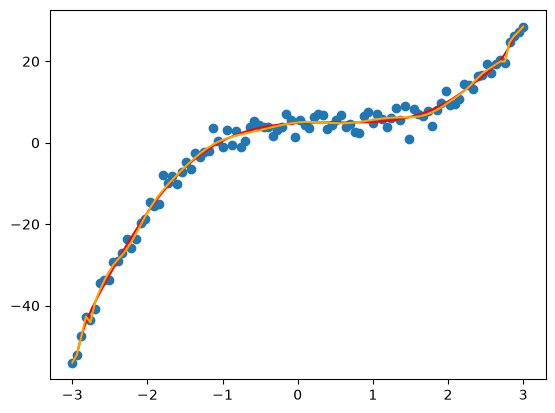

In [103]:
plt.scatter(X, y)
plt.plot(X, ls.predict(X_lasso), color='red')
plt.plot(X, lr.predict(X_lasso), color='orange')